In [1]:
from datamodule import GeoLifeCLEFSpeciesDataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs

DATA_DIR = "/home/thanasis.trantas/github_projects/gravity_wave_finetuning/data/finetune/geolifeclef24/aurorashape_species/val"

In [10]:
dataset = GeoLifeCLEFSpeciesDataset(data_dir=DATA_DIR, geo_size=(128,256))

lat_original = dataset[0]["lat_original"]
lon_original = dataset[0]["lon_original"]

In [7]:
def generate_baseline_coordinates(
    min_lon: float = -30.0,
    max_lon: float = 50.0,
    min_lat: float = 34.0,
    max_lat: float = 72.0,
    lon_step: float = 0.25,
    lat_step: float = 0.25
):
    """
    Generate baseline geographic coordinates for Europe using defined limits.

    Parameters:
      min_lon (float): Minimum longitude.
      max_lon (float): Maximum longitude.
      min_lat (float): Minimum latitude.
      max_lat (float): Maximum latitude.
      lon_step (float): Step size for longitude.
      lat_step (float): Step size for latitude.

    Returns:
      lat (np.ndarray): 1D array of latitudes (ascending order).
      lon (np.ndarray): 1D array of longitudes (ascending order).
    """
    # Increase stop a bit to ensure inclusion of endpoint.
    lat = np.arange(min_lat, max_lat + lat_step * 0.5, lat_step)
    lon = np.arange(min_lon, max_lon + lon_step * 0.5, lon_step)
    return lat, lon


def process_coordinates(lat_original, lon_original, sort_lat=True, sort_lon=True):
    """
    Process coordinate arrays, wrapping longitudes greater than 180° into [-180, 180)
    and optionally sorting them.

    Parameters:
      lat_original (list or array): Original latitudes.
      lon_original (list or array): Original longitudes.
      sort_lat (bool): Whether to sort latitudes.
      sort_lon (bool): Whether to wrap and sort longitudes.

    Returns:
      lat_sorted (np.ndarray): Processed latitudes.
      lon_sorted (np.ndarray): Processed longitudes.
      lat_sort_idx (np.ndarray or None): Sorting indices for latitudes.
      lon_sort_idx (np.ndarray or None): Sorting indices for longitudes.
    """
    lat_array = np.array(lat_original)
    if sort_lat:
        lat_sort_idx = np.argsort(lat_array)
        lat_sorted = lat_array[lat_sort_idx]
    else:
        lat_sorted = lat_array
        lat_sort_idx = None

    lon_array = np.array(lon_original)
    # Wrap if needed:
    lon_adjusted = np.where(lon_array > 180, lon_array - 360, lon_array)
    if sort_lon:
        lon_sort_idx = np.argsort(lon_adjusted)
        lon_sorted = lon_adjusted[lon_sort_idx]
    else:
        lon_sorted = lon_adjusted
        lon_sort_idx = None

    return lat_sorted, lon_sorted, lat_sort_idx, lon_sort_idx


def slice_coordinates(lat, lon, lat_range=None, lon_range=None, grid_size: tuple = None):
    """
    Select a subset of the coordinate arrays.

    This function now supports an optional `grid_size` parameter.
    If provided, grid_size = (n_lat, n_lon) returns the first n_lat values
    from the latitude array and the first n_lon values from the longitude array.
    Otherwise, lat_range and lon_range can be used.

    Parameters:
      lat (np.ndarray): 1D latitude array.
      lon (np.ndarray): 1D longitude array.
      lat_range (tuple, optional): (lat_min, lat_max) for slicing.
      lon_range (tuple, optional): (lon_min, lon_max) for slicing.
      grid_size (tuple, optional): (n_lat, n_lon) to choose the first n elements.

    Returns:
      lat_selected (np.ndarray): Sliced latitude values.
      lon_selected (np.ndarray): Sliced longitude values.
      lat_indices (np.ndarray): Indices of the selected latitudes.
      lon_indices (np.ndarray): Indices of the selected longitudes.
    """
    if grid_size is not None:
        n_lat, n_lon = grid_size
        n_lat = min(n_lat, len(lat))
        n_lon = min(n_lon, len(lon))
        lat_indices = np.arange(n_lat)
        lon_indices = np.arange(n_lon)
        lat_selected = lat[lat_indices]
        lon_selected = lon[lon_indices]
    else:
        if lat_range is not None:
            lat_mask = (lat >= lat_range[0]) & (lat <= lat_range[1])
            lat_selected = lat[lat_mask]
            lat_indices = np.where(lat_mask)[0]
        else:
            lat_selected = lat
            lat_indices = np.arange(len(lat))
        if lon_range is not None:
            lon_mask = (lon >= lon_range[0]) & (lon <= lon_range[1])
            lon_selected = lon[lon_mask]
            lon_indices = np.where(lon_mask)[0]
        else:
            lon_selected = lon
            lon_indices = np.arange(len(lon))
    return lat_selected, lon_selected, lat_indices, lon_indices


def slice_data(data, lat_indices, lon_indices):
    """
    Slice a data array (shape: [Channels, Lat, Lon]) using given indices.

    Parameters:
      data (np.ndarray): Data array with shape [Channels, Lat, Lon].
      lat_indices (np.ndarray): Indices to slice the latitude dimension.
      lon_indices (np.ndarray): Indices to slice the longitude dimension.

    Returns:
      np.ndarray: Sliced data of shape [Channels, len(lat_indices), len(lon_indices)].
    """
    return data[:, lat_indices, :][:, :, lon_indices]


###########################################
# 2. Toy Data Generation and Visualization#
###########################################
def generate_toy_data(n_channels, n_lat, n_lon):
    """
    Generate toy spatial data for demonstration.

    Each channel is built from a sine-cosine pattern with a phase offset.

    Parameters:
      n_channels (int): Number of channels.
      n_lat (int): Number of latitude points.
      n_lon (int): Number of longitude points.

    Returns:
      np.ndarray: Toy data array of shape [n_channels, n_lat, n_lon].
    """
    x, y = np.meshgrid(np.linspace(0, 2 * np.pi, n_lon),
                       np.linspace(0, 2 * np.pi, n_lat))
    data = np.empty((n_channels, n_lat, n_lon))
    for c in range(n_channels):
        data[c] = np.sin(x + c * 0.5) * np.cos(y + c * 0.5)
    return data


def plot_channel_with_overlay(
    full_lat, full_lon, overlay_data, overlay_lat, overlay_lon,
    channel_idx=0, title=None, cmap='viridis'
):
    """
    Plot the full map (using the full coordinate arrays) and overlay a smaller
    region with data (the sliced data). The overlay is drawn using its own
    coordinate arrays and a semi-transparent contourf so that you can see
    the underlying full map. A red rectangle is drawn around the overlay extent.

    Parameters:
      full_lat (np.ndarray): Full latitude array of the background map.
      full_lon (np.ndarray): Full longitude array of the background map.
      overlay_data (np.ndarray): Data array for the overlay, with shape [n_overlay_lat, n_overlay_lon].
      overlay_lat (np.ndarray): Latitude values corresponding to the overlay data.
      overlay_lon (np.ndarray): Longitude values corresponding to the overlay data.
      channel_idx (int): Index of the channel (for title purposes).
      title (str, optional): Title for the plot.
      cmap (str): Colormap.
    """
    fig, ax = plt.subplots(
        subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 8)
    )
    # Set the extent to show the full region.
    full_extent = [full_lon[0], full_lon[-1], full_lat[0], full_lat[-1]]
    ax.set_extent(full_extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m")
    ax.set_title(title if title is not None else f"Channel {channel_idx} with Overlay")

    # Now overlay the sliced data:
    # Create meshgrid for the overlay coordinates.
    overlay_lon_grid, overlay_lat_grid = np.meshgrid(overlay_lon, overlay_lat)
    cf = ax.contourf(
        overlay_lon_grid, overlay_lat_grid, overlay_data,
        levels=60, cmap=cmap, transform=ccrs.PlateCarree(), alpha=0.7
    )
    # Draw rectangle around the overlay area.
    overlay_extent = [overlay_lon[0], overlay_lon[-1], overlay_lat[0], overlay_lat[-1]]
    rect = Rectangle(
        (overlay_extent[0], overlay_extent[2]),
        overlay_extent[1] - overlay_extent[0],
        overlay_extent[3] - overlay_extent[2],
        linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)
    fig.colorbar(cf, ax=ax, orientation="vertical", label="Value")
    plt.tight_layout()
    plt.show()

Full baseline latitudes: [72.   71.75 71.5  71.25 71.   70.75 70.5  70.25 70.   69.75 69.5  69.25
 69.   68.75 68.5  68.25 68.   67.75 67.5  67.25 67.   66.75 66.5  66.25
 66.   65.75 65.5  65.25 65.   64.75 64.5  64.25 64.   63.75 63.5  63.25
 63.   62.75 62.5  62.25 62.   61.75 61.5  61.25 61.   60.75 60.5  60.25
 60.   59.75 59.5  59.25 59.   58.75 58.5  58.25 58.   57.75 57.5  57.25
 57.   56.75 56.5  56.25 56.   55.75 55.5  55.25 55.   54.75 54.5  54.25
 54.   53.75 53.5  53.25 53.   52.75 52.5  52.25 52.   51.75 51.5  51.25
 51.   50.75 50.5  50.25 50.   49.75 49.5  49.25 49.   48.75 48.5  48.25
 48.   47.75 47.5  47.25 47.   46.75 46.5  46.25 46.   45.75 45.5  45.25
 45.   44.75 44.5  44.25 44.   43.75 43.5  43.25 43.   42.75 42.5  42.25
 42.   41.75 41.5  41.25 41.   40.75 40.5  40.25 40.   39.75 39.5  39.25
 39.   38.75 38.5  38.25 38.   37.75 37.5  37.25 37.   36.75 36.5  36.25
 36.   35.75 35.5  35.25 35.   34.75 34.5  34.25]
Full baseline longitudes: [-30.   -29.75 -29.5  -

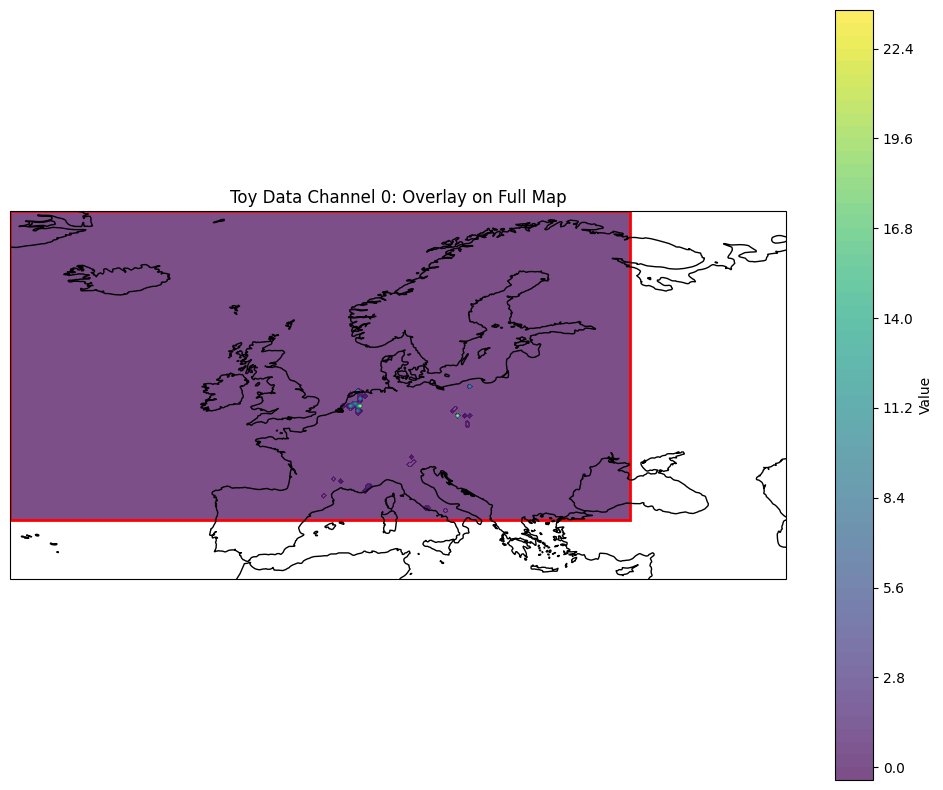

In [12]:
# Process and sort coordinates
# lat_sorted, lon_sorted, lat_idx, lon_idx = process_coordinates(lat_original, lon_original, sort_lat=True, sort_lon=True)

# Print basic info on the processed coordinates.
# print("Processed Latitudes:", lat_sorted)
# print("Processed Longitudes:", lon_sorted)

# full_lat, full_lon = generate_baseline_coordinates()

full_lat, full_lon = np.asarray(lat_original), np.asarray(lon_original)
print("Full baseline latitudes:", full_lat)
print("Full baseline longitudes:", full_lon)

# We need to slice a small grid of e.g. (12,24)
grid_size = (128, 256)
overlay_lat, overlay_lon, lat_sel_idx, lon_sel_idx = slice_coordinates(full_lat, full_lon, grid_size=grid_size)
print("Overlay latitudes (sliced):", overlay_lat)
print("Overlay longitudes (sliced):", overlay_lon)

# Generate toy data over the full grid.
n_channels = 3  # number of channels to experiment with
toy_data_full = generate_toy_data(n_channels, n_lat=len(full_lat), n_lon=len(full_lon))

real_data = dataset[0]["y"]
print(real_data.shape)
new_data = real_data.numpy()

# Slice the toy data to obtain the overlay for the chosen subregion.
toy_data_overlay = slice_data(new_data, lat_sel_idx, lon_sel_idx)
# For illustration, choose the first channel.
overlay_channel_data = toy_data_overlay[0]

# Plot the full map with the overlay.
plot_channel_with_overlay(
    full_lat=full_lat,
    full_lon=full_lon,
    overlay_data=overlay_channel_data,
    overlay_lat=overlay_lat,
    overlay_lon=overlay_lon,
    channel_idx=0,
    title="Toy Data Channel 0: Overlay on Full Map",
    cmap='viridis'
)

# Slice the toy data to the selected coordinate region.
# real_data = dataset[0]["y"]
# print(real_data.shape)
# new_data = real_data.numpy()
# new_data_sliced = slice_data(new_data, lat_sel_idx, lon_sel_idx)